In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# df = pd.read_csv(
#     '../Datasets/housing.xls',
#     delim_whitespace=True,
#     header=None
# )
# df.columns = [
#     'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX',
#     'RM', 'AGE', 'DIS', 'RAD', 'TAX',
#     'PTRATIO', 'B', 'LSTAT', 'MEDV'
# ]
# df.to_csv('../Datasets/housing.csv', index=False)


/tmp/ipykernel_68965/547395596.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [15]:
df = pd.read_csv('../Datasets/boston_housing.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [21]:
df.columns = [
    'per_capita_crime_rate',                 # CRIM
    'residential_land_zoned_percent',        # ZN
    'non_retail_business_acres_percent',     # INDUS
    'charles_river_dummy',                   # CHAS
    'nitric_oxides_concentration',            # NOX
    'average_rooms_per_dwelling',             # RM
    'owner_occupied_units_built_pre_1940',   # AGE
    'weighted_distance_to_employment_centers', # DIS
    'accessibility_to_radial_highways',       # RAD
    'property_tax_rate',                      # TAX
    'pupil_teacher_ratio',                    # PTRATIO
    'black_population_proportion',            # B
    'lower_status_population_percent',        # LSTAT
    'median_home_value'                       # MEDV (target)
]


In [22]:
df.describe()

,per_capita_crime_rate,residential_land_zoned_percent,non_retail_business_acres_percent,charles_river_dummy,nitric_oxides_concentration,average_rooms_per_dwelling,owner_occupied_units_built_pre_1940,weighted_distance_to_employment_centers,accessibility_to_radial_highways,property_tax_rate,pupil_teacher_ratio,black_population_proportion,lower_status_population_percent,median_home_value
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   per_capita_crime_rate                    506 non-null    float64
 1   residential_land_zoned_percent           506 non-null    float64
 2   non_retail_business_acres_percent        506 non-null    float64
 3   charles_river_dummy                      506 non-null    int64  
 4   nitric_oxides_concentration              506 non-null    float64
 5   average_rooms_per_dwelling               506 non-null    float64
 6   owner_occupied_units_built_pre_1940      506 non-null    float64
 7   weighted_distance_to_employment_centers  506 non-null    float64
 8   accessibility_to_radial_highways         506 non-null    int64  
 9   property_tax_rate                        506 non-null    float64
 10  pupil_teacher_ratio                      506 non-n

In [25]:
df.isnull().sum()

per_capita_crime_rate                      0
residential_land_zoned_percent             0
non_retail_business_acres_percent          0
charles_river_dummy                        0
nitric_oxides_concentration                0
average_rooms_per_dwelling                 0
owner_occupied_units_built_pre_1940        0
weighted_distance_to_employment_centers    0
accessibility_to_radial_highways           0
property_tax_rate                          0
pupil_teacher_ratio                        0
black_population_proportion                0
lower_status_population_percent            0
median_home_value                          0
dtype: int64

array([[<Axes: title={'center': 'per_capita_crime_rate'}>,
        <Axes: title={'center': 'residential_land_zoned_percent'}>,
        <Axes: title={'center': 'non_retail_business_acres_percent'}>,
        <Axes: title={'center': 'charles_river_dummy'}>],
       [<Axes: title={'center': 'nitric_oxides_concentration'}>,
        <Axes: title={'center': 'average_rooms_per_dwelling'}>,
        <Axes: title={'center': 'owner_occupied_units_built_pre_1940'}>,
        <Axes: title={'center': 'weighted_distance_to_employment_centers'}>],
       [<Axes: title={'center': 'accessibility_to_radial_highways'}>,
        <Axes: title={'center': 'property_tax_rate'}>,
        <Axes: title={'center': 'pupil_teacher_ratio'}>,
        <Axes: title={'center': 'black_population_proportion'}>],
       [<Axes: title={'center': 'lower_status_population_percent'}>,
        <Axes: title={'center': 'median_home_value'}>, <Axes: >,
        <Axes: >]], dtype=object)

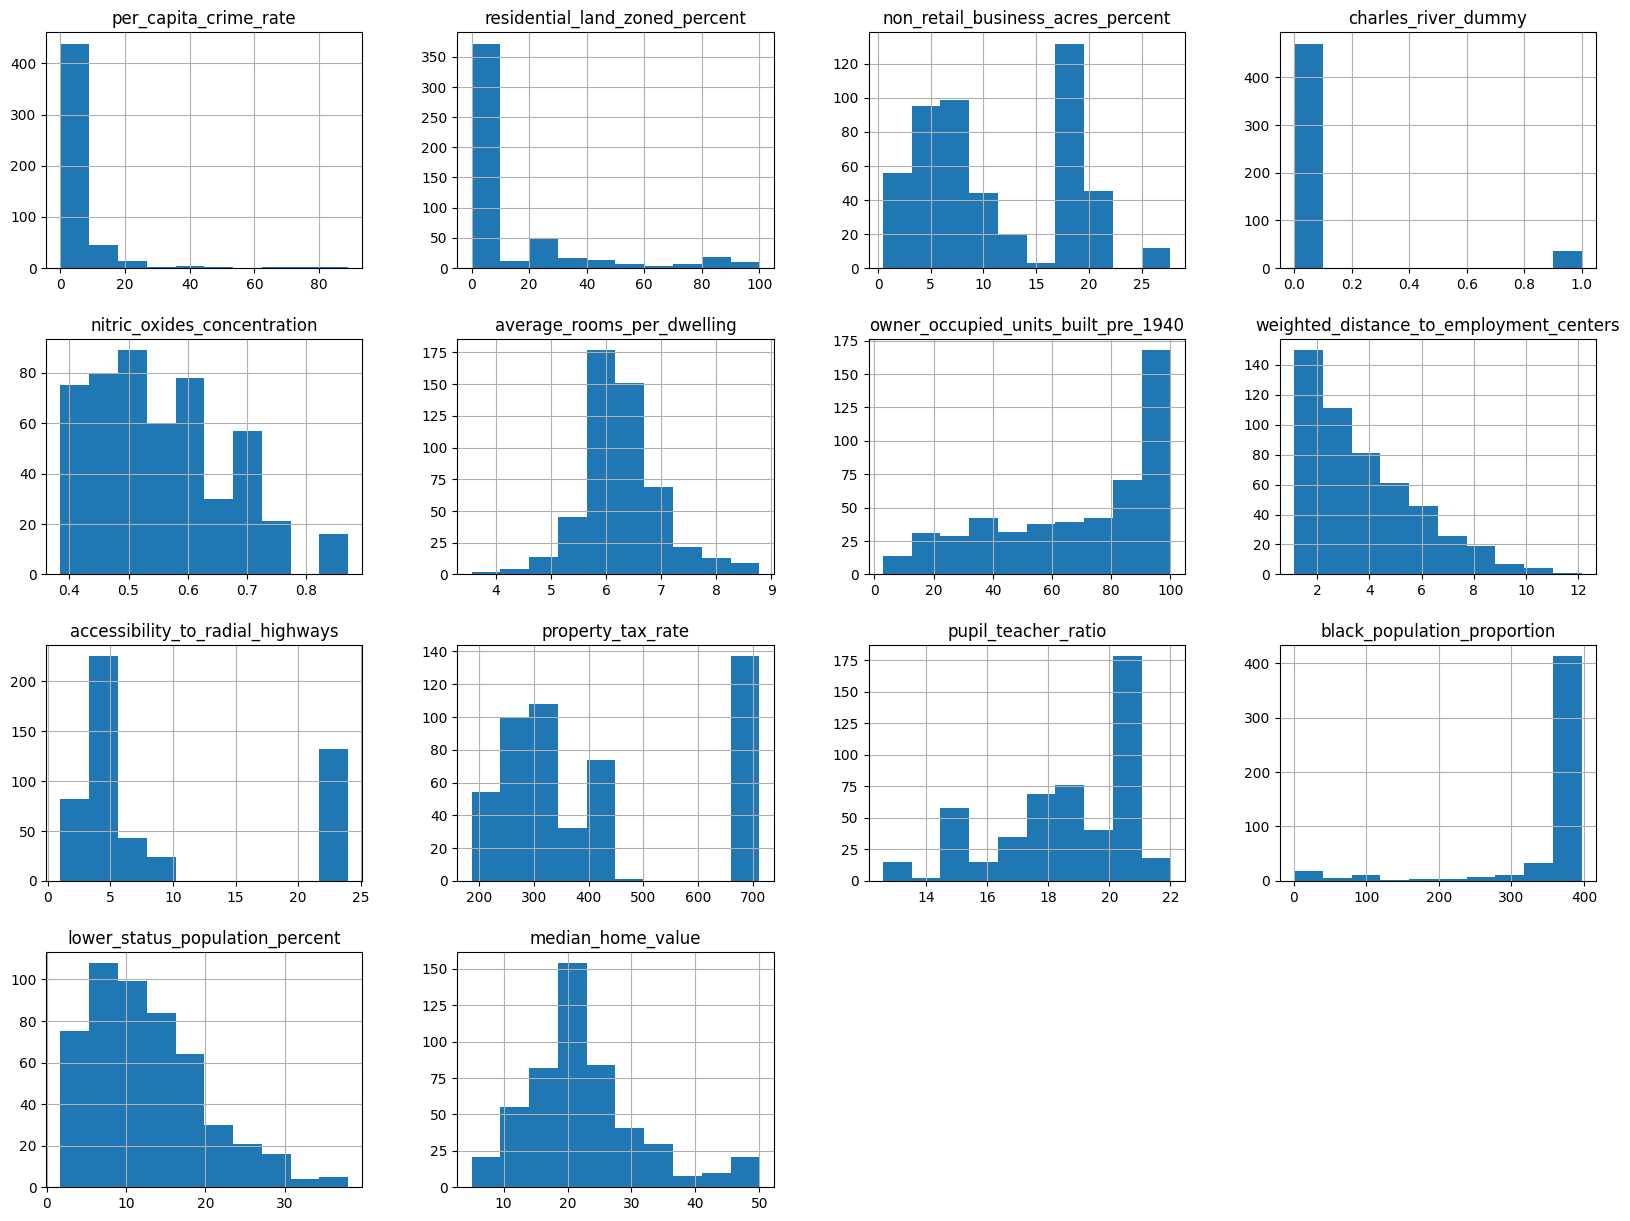

In [28]:
df.hist( figsize=(20,15) )

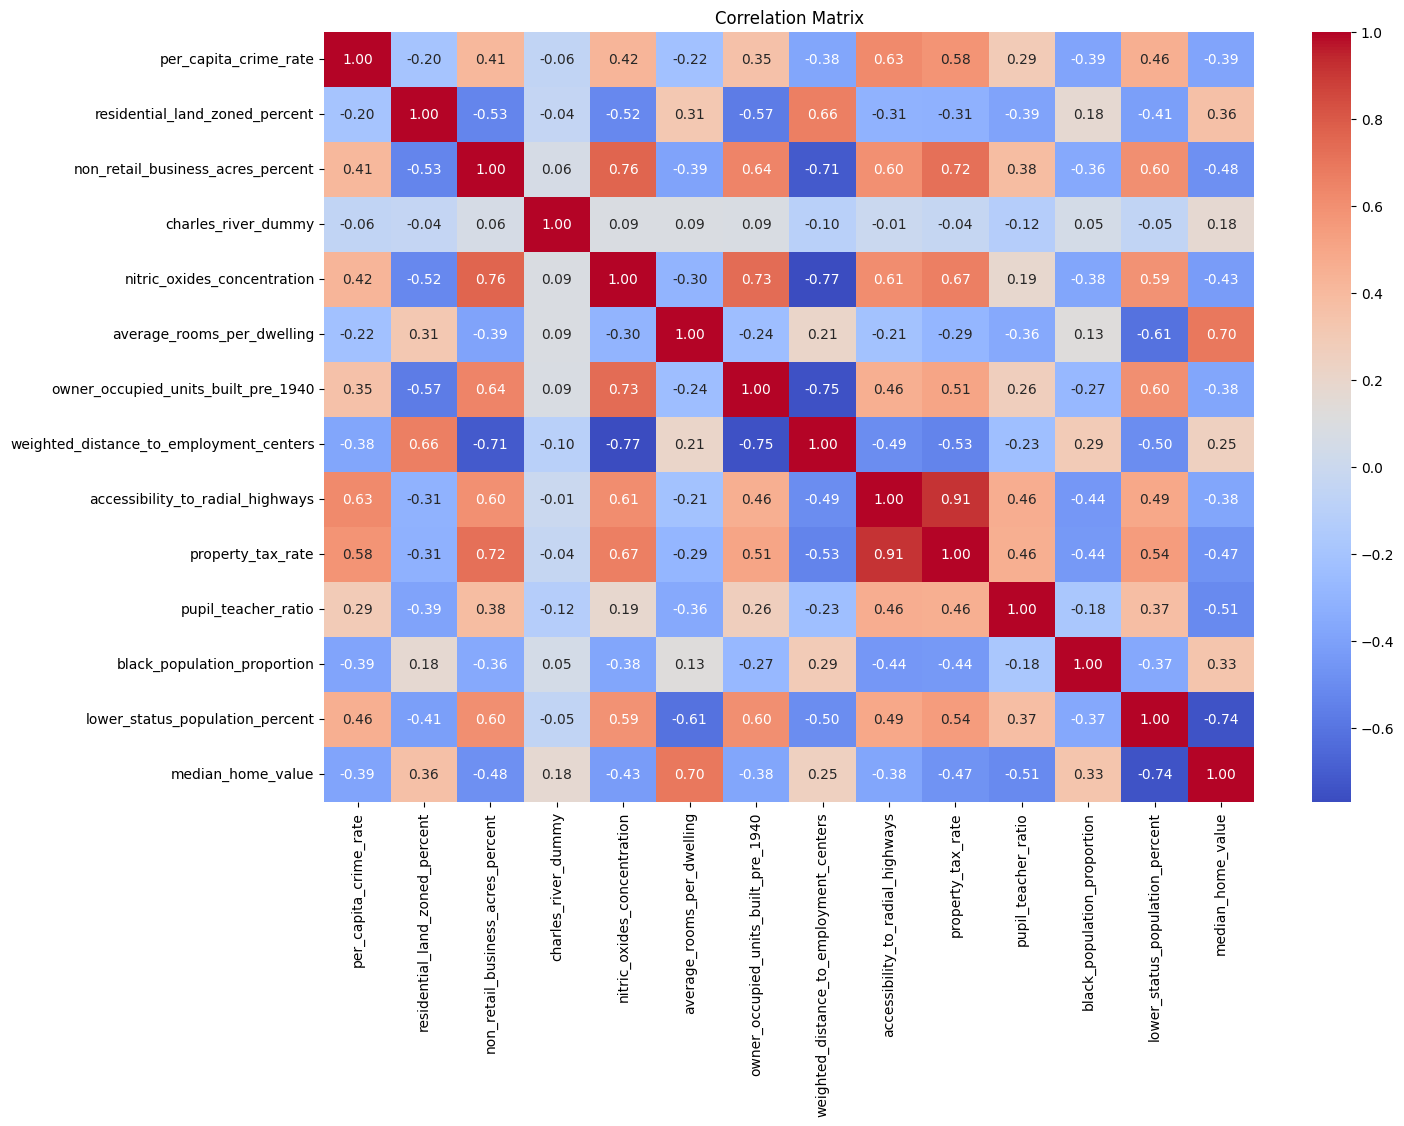

In [33]:
corr_matrix = df.corr()
plt.figure( figsize=(15,10) )
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [34]:
X = df.drop('median_home_value', axis=1)
y = df['median_home_value']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(404, 13) (102, 13) (404,) (102,)


In [50]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

model = XGBRegressor()
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [52]:
train_pred = model.predict(X_train)
train_pred_r2 = r2_score(y_train, train_pred)
print(f'Training R2 Score: {train_pred_r2}')
train_pred_mse = mean_squared_error(y_train, train_pred)
print(f'Training MSE: {train_pred_mse}')

Training R2 Score: 0.9999969829984965
Training MSE: 0.0002620971899759447


In [53]:
test_pred = model.predict(X_test)
test_pred_r2 = r2_score(y_test, test_pred)
print(f'Testing R2 Score: {test_pred_r2}')
test_pred_mse = mean_squared_error(y_test, test_pred)
print(f'Testing MSE: {test_pred_mse}')

Testing R2 Score: 0.9057837838492537
Testing MSE: 6.909231565384943


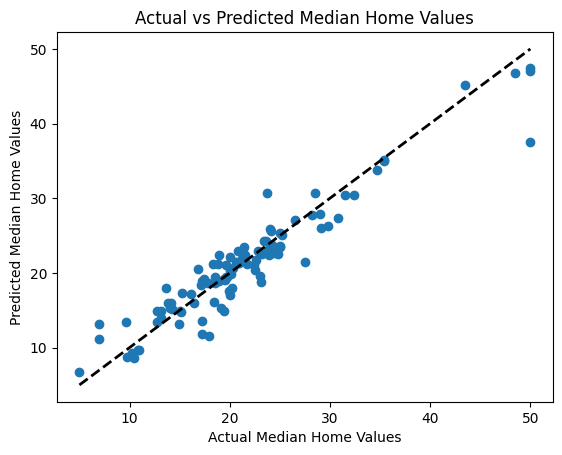

In [57]:
plt.scatter(y_test, test_pred)
plt.xlabel('Actual Median Home Values')
plt.ylabel('Predicted Median Home Values')
plt.title('Actual vs Predicted Median Home Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()